## About this notebook — `scanned_small_pipeline.ipynb`

**Purpose:** Compact, fast interactive pipeline for high-quality **scanned** fingerprint images.
Uses sensible defaults — intended for students getting started or for quick parameter exploration.

| | |
|---|---|
| **Input** | High-quality scanned fingerprint (white background, high contrast) |
| **Output** | Skeleton overlay, minutiae visualisation |
| **Pipeline** | ipywidgets sliders — re-executes on every slider change |
| **Best for** | Quick first look at a scanned fingerprint; learning the basics |

### Methods used
`variance ROI mask` · `CLAHE` · `adaptive binarization` · `morphology cleanup` ·
`skeletonization` · `minutiae extraction (crossing number)`

---

### Notebook comparison

| | Notebook | Input | Output | Pipeline | Best for |
|---|:---|:---|:---|:---|:---|
| | scanning | Live scanner | Captured images | Buttons | Acquire fingerprints from hardware |
| ▶ | **scanned_small_pipeline** | Scanned image | Skeleton + minutiae | Widget sliders | Quick processing, sensible defaults |
| | scanned_full_pipeline | Scanned image | Skeleton + minutiae | Widget sliders + toggles | Full parameter control, scanned FP |
| | photo_finger | Photo (dark background) | Skeleton + minutiae | Widget sliders | Full photo pipeline (ImageJ-based) |
| | ridge_valley | Photo or scanned | Valley print map | Widgets + polygon ROI | Valley extraction with manual ROI |
| | photo_valley_pipeline | Photo | Valley print map | Static comparisons | Experiment with photo → valley methods |
| | algorithms_explorer | Any | Side-by-side comparisons | Static comparisons | Learn and compare all available algorithms |


# Scanned Fingerprints — Small Interactive Pipeline

This notebook rewrites the older scan-processing notebook into a **smaller preset-driven workflow** using the new:

- `InteractivePipeline`
- `Step`
- `pipeline_presets`

It focuses on a few core steps relevant for **good-quality scanned fingerprints**:

1. foreground mask
2. apply mask
3. CLAHE
4. binarization
5. binary masking
6. optional morphology
7. skeletonization
8. optional minutiae extraction

The notebook is intentionally lightweight and uses only functions that were listed in `methods_prototypes`.


In [1]:
# ============================================================
# PROJECT PATH SETUP
# ============================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "fingerprints"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)


PROJECT_ROOT: /home/x232886/PycharmProjects/PV080_biometrics
SRC_DIR: /home/x232886/PycharmProjects/PV080_biometrics/fingerprints


In [2]:
import importlib
import fingerprints.pipeline_presets
import fingerprints.interactive

importlib.reload(fingerprints.interactive)
importlib.reload(fingerprints.pipeline_presets)

import fingerprints.pipeline_presets as pp
import fingerprints.interactive as ip

print("pipeline_presets:", pp.__file__)
print("interactive:", ip.__file__)

pipeline_presets: /home/x232886/PycharmProjects/PV080_biometrics/fingerprints/pipeline_presets.py
interactive: /home/x232886/PycharmProjects/PV080_biometrics/fingerprints/interactive.py


Loaded: /home/x232886/PycharmProjects/PV080_biometrics/images/scanned/right2.png
Shape: (480, 320) dtype: uint8


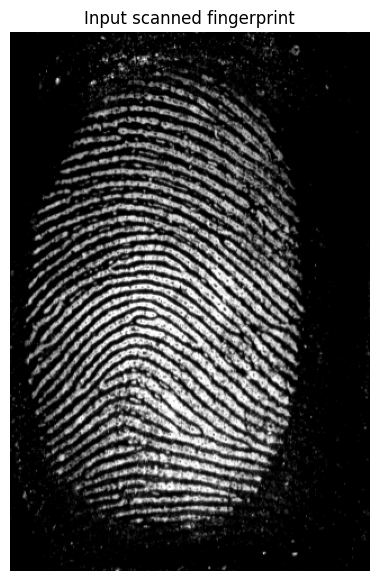

In [3]:
# ============================================================
# LOAD SCANNED IMAGE
# ============================================================

from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Change this path as needed
IMAGE_PATH = PROJECT_ROOT / "images" / "scanned" / "right2.png"

img = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise RuntimeError(f"Failed to load image: {IMAGE_PATH}")

print("Loaded:", IMAGE_PATH)
print("Shape:", img.shape, "dtype:", img.dtype)

plt.figure(figsize=(5, 7))
plt.imshow(img, cmap="gray")
plt.title("Input scanned fingerprint")
plt.axis("off")
plt.show()


## Build a small scan preset

This notebook does **not** use the full home-photo pipeline.

Instead it builds a compact custom order for scanned fingers with narrow, practical defaults.


In [4]:
# ============================================================
# IMPORT PRESET HELPERS
# ============================================================

from fingerprints.pipeline_presets import make_custom_pipeline, available_operation_keys

print("Available operation keys:")
print(available_operation_keys())


Available operation keys:
['apply_mask_zero', 'binarize', 'ced', 'channel_select', 'clahe', 'dog', 'dynamic_gabor', 'fft_bandpass', 'foreground_mask', 'gabor_rebuild', 'gamma', 'local_contrast', 'mask_binary', 'mask_black_bg', 'minutiae_vis', 'morphology', 'prune_skeleton', 'ridge_filter', 'roi_segmentation_vis', 'skeleton_vis', 'stretch']


In [5]:
SCAN_BASIC_ORDER = [
    # ROI
    "mask_black_bg",
    "apply_mask",

    # Contrast / normalization
    "clahe",
    "gamma",
    "local_contrast",

    # Smoothing
    "median_blur",
    "gaussian_blur",

    # Enhancement
    "dog",
    "fft_bandpass",
    "meijering",
    "ridge_filter",
    "gabor_static",
    "dynamic_gabor",

    # Binarization
    "binarize",
    "mask_binary",

    # Post-processing
    "morphology",

    # Structure
    "skeleton",
    "prune_skeleton",
    "minutiae",
]

SCAN_BASIC_ENABLED = {
    "mask_black_bg": True,
    "apply_mask": True,

    "clahe": True,
    "gamma": True,
    "local_contrast": False,

    "median_blur": True,
    "gaussian_blur": False,

    "dog": True,
    "fft_bandpass": False,
    "meijering": True,
    "ridge_filter": True,
    "gabor_static": False,
    "dynamic_gabor": False,

    "binarize": True,
    "mask_binary": True,

    "morphology": False,

    "skeleton": True,
    "prune_skeleton": False,
    "minutiae": False,
}

SCAN_BASIC_OVERRIDES = {
    "mask_black_bg": {
        "threshold": {"kind": "int", "value": 31, "min": 0, "max": 80, "step": 1, "label": "BG thresh"},
    },

    "clahe": {
        "clip": {"kind": "float", "value": 2.0, "min": 0.5, "max": 5.0, "step": 0.1, "label": "Clip"},
        "tile": {"kind": "int", "value": 8, "min": 2, "max": 16, "step": 2, "label": "Tile"},
    },

    "gamma": {
        "gamma": {"kind": "float", "value": 0.6, "min": 0.2, "max": 2.0, "step": 0.05, "label": "Gamma"},
    },

    "local_contrast": {
        "radius": {"kind": "int", "value": 15, "min": 3, "max": 61, "step": 2, "label": "Radius"},
        "amount": {"kind": "float", "value": 1.0, "min": 0.2, "max": 3.0, "step": 0.1, "label": "Amount"},
    },

    "median_blur": {
        "ksize": {"kind": "int", "value": 5, "min": 3, "max": 15, "step": 2, "label": "Median"},
    },

    "gaussian_blur": {
        "ksize": {"kind": "int", "value": 7, "min": 3, "max": 21, "step": 2, "label": "Gaussian"},
        "sigma": {"kind": "float", "value": 1.5, "min": 0.1, "max": 5.0, "step": 0.1, "label": "Sigma"},
    },

    "dog": {
        "sigma1": {"kind": "float", "value": 1.0, "min": 0.2, "max": 5.0, "step": 0.1, "label": "Sigma1"},
        "sigma2": {"kind": "float", "value": 2.0, "min": 0.5, "max": 10.0, "step": 0.1, "label": "Sigma2"},
        "gain": {"kind": "float", "value": 1.0, "min": 0.2, "max": 3.0, "step": 0.1, "label": "Gain"},
    },

    "fft_bandpass": {
        "low_sigma": {"kind": "float", "value": 20.0, "min": 1.0, "max": 60.0, "step": 1.0, "label": "Low σ"},
        "high_sigma": {"kind": "float", "value": 80.0, "min": 10.0, "max": 150.0, "step": 1.0, "label": "High σ"},
    },

    "meijering": {
        "sigmas": {
            "kind": "choice",
            "value": (1, 2, 3),
            "options": [
                ((1,), "1"),
                ((1, 2), "1,2"),
                ((1, 2, 3), "1,2,3"),
            ],
            "label": "Sigmas",
        },
    },

    "ridge_filter": {
        "sigma": {"kind": "float", "value": 2.0, "min": 0.5, "max": 6.0, "step": 0.1, "label": "Sigma"},
    },

    "gabor_static": {
        "ksize": {"kind": "int", "value": 21, "min": 7, "max": 51, "step": 2, "label": "Kernel"},
        "sigma": {"kind": "float", "value": 4.0, "min": 1.0, "max": 10.0, "step": 0.1, "label": "Sigma"},
        "theta": {"kind": "float", "value": 0.0, "min": 0.0, "max": 3.14, "step": 0.1, "label": "Theta"},
    },

    "dynamic_gabor": {
        "orient_block": {"kind": "int", "value": 16, "min": 4, "max": 64, "step": 2, "label": "Ori blk"},
        "freq_block": {"kind": "int", "value": 32, "min": 8, "max": 96, "step": 2, "label": "Freq blk"},
        "sigma_base": {"kind": "float", "value": 4.0, "min": 1.0, "max": 10.0, "step": 0.1, "label": "Sigma"},
    },

    "binarize": {
        "method": {
            "kind": "choice",
            "value": "adaptive",
            "options": ["adaptive", "otsu", "li", "sauvola"],
            "label": "Method",
        },
        "block_size": {"kind": "int", "value": 31, "min": 9, "max": 81, "step": 2, "label": "Block"},
        "C": {"kind": "int", "value": 5, "min": -10, "max": 20, "step": 1, "label": "C"},
        "invert": {"kind": "bool", "value": True, "label": "Invert"},
    },

    "morphology": {
        "open_ksize": {"kind": "int", "value": 0, "min": 0, "max": 7, "step": 1, "label": "Open"},
        "close_ksize": {"kind": "int", "value": 0, "min": 0, "max": 7, "step": 1, "label": "Close"},
        "dilate_ksize": {"kind": "int", "value": 0, "min": 0, "max": 5, "step": 1, "label": "Dilate"},
        "erode_ksize": {"kind": "int", "value": 0, "min": 0, "max": 5, "step": 1, "label": "Erode"},
    },

    "minutiae": {
        "border_margin": {"kind": "int", "value": 10, "min": 0, "max": 30, "step": 1, "label": "Margin"},
    },
}

In [6]:
# ============================================================
# CREATE AND DISPLAY PIPELINE
# ============================================================

pipeline = make_custom_pipeline(
    img,
    order=SCAN_BASIC_ORDER,
    enabled_map=SCAN_BASIC_ENABLED,
    per_step_param_overrides=SCAN_BASIC_OVERRIDES,
    preset_name="scan_basic_demo",
)

display(pipeline.display())

[build_pipeline_steps] skipping missing operation: apply_mask
[build_pipeline_steps] skipping missing operation: median_blur
[build_pipeline_steps] skipping missing operation: gaussian_blur
[build_pipeline_steps] skipping missing operation: meijering
[build_pipeline_steps] skipping missing operation: gabor_static
[build_pipeline_steps] skipping missing operation: skeleton
[build_pipeline_steps] skipping missing operation: minutiae


In [9]:
mask = pipeline.context.get("mask")
print(type(mask), mask.shape if mask is not None else None, mask.dtype if mask is not None else None)

if mask is not None:
    import numpy as np
    print("min/max:", np.min(mask), np.max(mask))
    print("unique sample:", np.unique(mask)[:20])

<class 'numpy.ndarray'> (480, 320) uint8
min/max: 0 255
unique sample: [  0 255]


## Save tuned parameters

After experimenting with sliders and toggles, save the current state to JSON.


In [ ]:
# ============================================================
# EXPORT CURRENT PIPELINE SETTINGS
# ============================================================

EXPORT_PATH = PROJECT_ROOT / "scan_basic_demo_params.json"

pipeline.export_params_json(str(EXPORT_PATH))
print("Saved:", EXPORT_PATH)
print(pipeline.get_params())


## Reload parameters later

Use this cell when you want to restore a previously saved configuration.


In [ ]:
# ============================================================
# RELOAD SAVED SETTINGS
# ============================================================

IMPORT_PATH = PROJECT_ROOT / "scan_basic_demo_params.json"

if IMPORT_PATH.exists():
    pipeline.import_params_json(str(IMPORT_PATH), rerun=True)
    print("Loaded:", IMPORT_PATH)
else:
    print("File does not exist yet:", IMPORT_PATH)
